# seaborn practice

## 주제
당신은 온라인 강의 플랫폼의 데이터 분석 담당자이다.  
이번 주에는 "수강생 행동 데이터를 바탕으로 학습 패턴을 시각화"해야 한다.

## 목표
- seaborn으로 범주형/수치형 데이터를 쉽게 시각화하기
- matplotlib과 비교했을 때 seaborn이 왜 편한지 체감하기
- histplot, countplot, boxplot, heatmap, scatterplot, regplot, pairplot 사용하기

In [2]:
%conda install numpy

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 공통 데이터 준비

아래 데이터는 강의 플랫폼의 수강생 활동 로그를 단순화한 예시이다.
- study_hours: 주간 공부 시간
- practice_count: 주간 실습 제출 수
- score: 평가 점수
- track: 과정 트랙
- level: 선수 수준
- completed: 수료 여부

In [4]:
student_df = pd.DataFrame({
    'study_hours': [4, 6, 3, 8, 10, 7, 5, 9, 11, 6, 12, 13],
    'practice_count': [1, 2, 1, 3, 4, 3, 2, 4, 5, 2, 5, 5],
    'score': [55, 62, 50, 71, 82, 74, 66, 85, 91, 68, 94, 96],
    'track': ['웹', '웹', '데이터', '데이터', 'AI', 'AI', '웹', '데이터', 'AI', '웹', 'AI', '데이터'],
    'level': ['입문', '입문', '입문', '기초', '기초', '기초', '기초', '중급', '중급', '중급', '중급', '중급'],
    'completed': ['N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y']
})

student_df

,study_hours,practice_count,score,track,level,completed
0,4,1,55,웹,입문,N
1,6,2,62,웹,입문,N
2,3,1,50,데이터,입문,N
3,8,3,71,데이터,기초,Y
4,10,4,82,AI,기초,Y
5,7,3,74,AI,기초,Y
6,5,2,66,웹,기초,Y
7,9,4,85,데이터,중급,Y
8,11,5,91,AI,중급,Y
9,6,2,68,웹,중급,Y


## 문제 1. 점수 분포 Histogram

운영팀은 전체 점수 분포를 먼저 보고 싶어 한다.

요구사항
1. score 컬럼으로 histplot을 그린다.
2. bins=6으로 설정한다.
3. kde=True를 설정한다.
4. 제목은 '수강생 점수 분포'로 설정한다.

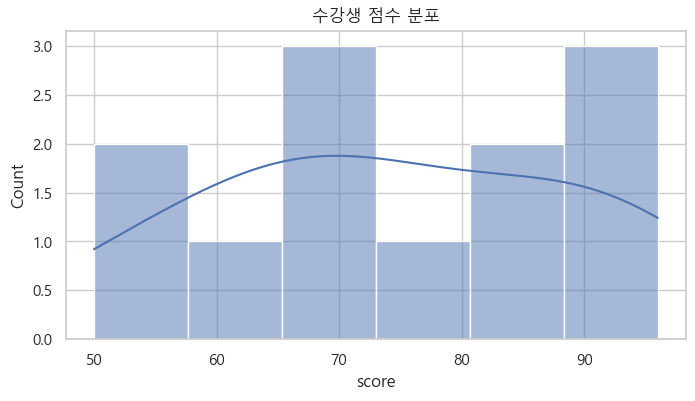

In [ ]:
# TODO: histplot 완성하기
plt.figure(figsize=(8, 4))

sns.histplot(student_df['score'], bins=6, kde=True)
plt.title("수강생 점수 분포")

plt.show()

## 문제 2. 트랙별 수강생 수 Count Plot

요구사항
1. x축은 track으로 한다.
2. completed를 hue로 구분한다.
3. 제목은 '트랙별 수강생 수와 수료 여부'로 설정한다.

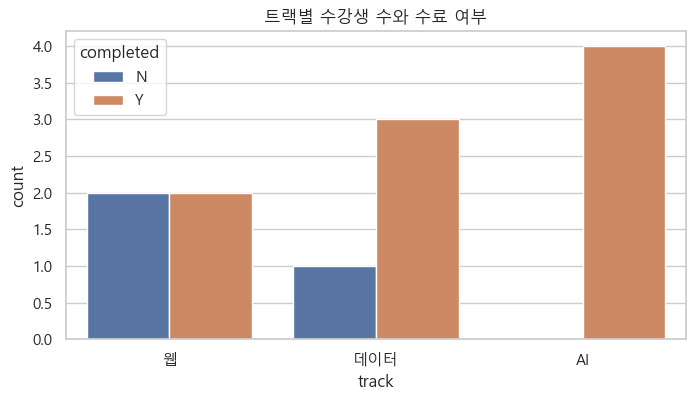

In [ ]:
# TODO: countplot 완성하기
plt.figure(figsize=(8, 4))

sns.countplot(x=student_df['track'], hue=student_df['completed'])
plt.title("트랙별 수강생 수와 수료 여부")

plt.show()

## 문제 3. 트랙별 점수 분포 Box Plot

과정 기획팀은 트랙별 점수 분포 차이를 보고 싶어 한다.

요구사항
1. x='track', y='score'로 boxplot을 그린다.
2. 제목은 '트랙별 점수 분포'로 설정한다.

질문
트랙별 중앙값 차이가 있는가? O
어느 트랙의 분산이 가장 큰가? 데이터 

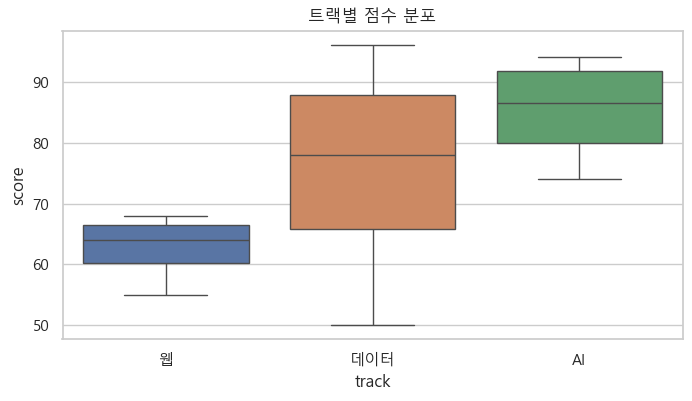

In [ ]:
# TODO: boxplot 완성하기

plt.figure(figsize=(8, 4))

sns.boxplot(data=student_df, x=student_df['track'], y=student_df['score'], hue='track')
plt.title("트랙별 점수 분포")

plt.show()

## 문제 4. 수치형 컬럼 상관관계 Heatmap

분석팀은 공부 시간, 실습 수, 점수 사이의 관계를 한눈에 보고 싶어 한다.

요구사항
1. study_hours, practice_count, score 컬럼만 선택한다.
2. corr()로 상관계수 행렬을 구한다.
3. heatmap에서 annot=True를 사용한다.
4. cmap은 'YlGnBu'를 사용한다.

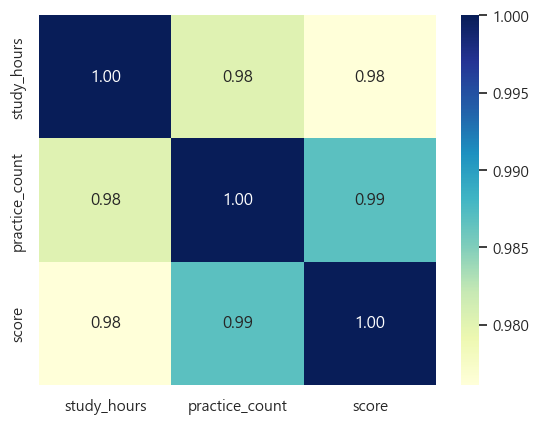

In [ ]:
corr_mat = student_df.corr(numeric_only=True)
corr_mat

sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='YlGnBu')
plt.show()

## 문제 5. 공부 시간과 점수의 관계 Scatter Plot

요구사항
1. x='study_hours', y='score'로 scatterplot을 그린다.
2. hue는 track으로 설정한다.
3. size는 practice_count로 설정한다.
4. 제목은 '공부 시간과 점수의 관계'로 설정한다.

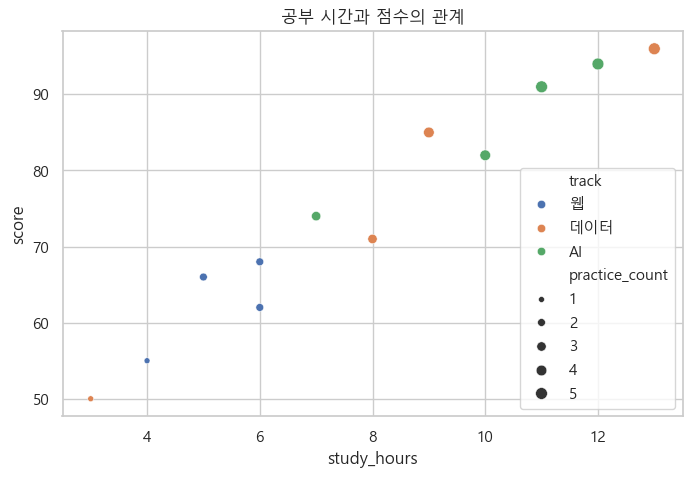

In [ ]:
# TODO: scatterplot 완성하기
plt.figure(figsize=(8, 5))

sns.scatterplot(data=student_df, x='study_hours', y='score',
                hue='track', size='practice_count')
plt.title("공부 시간과 점수의 관계")

plt.show()

## 문제 6. 회귀선까지 포함한 관계 보기 Reg Plot

운영팀은 공부 시간이 늘면 점수가 정말 올라가는지 회귀선으로도 보고 싶어 한다.

요구사항
1. x='study_hours', y='score'로 regplot을 그린다.
2. scatter_kws={'s': 80}를 사용한다.
3. 제목은 '공부 시간과 점수의 회귀선'으로 설정한다.
   
질문
공부 시간과 점수 사이에 어떤 관계가 보이는가? 공부한 시간이 많을 수록 점수가 높다.

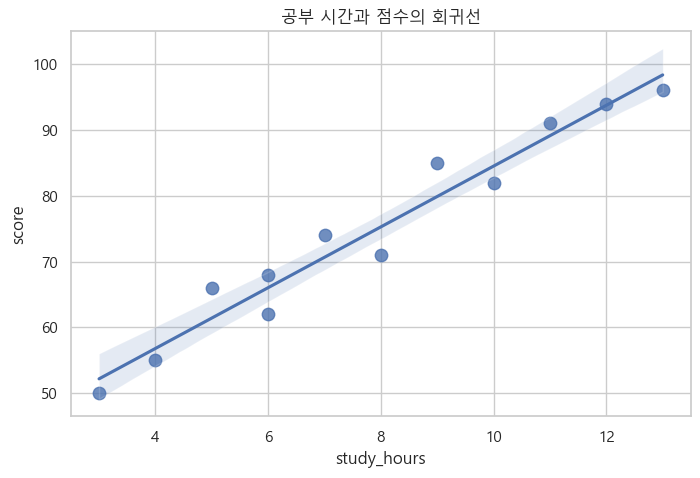

In [ ]:
# TODO: regplot 완성하기
plt.figure(figsize=(8, 5))

sns.regplot(data=student_df,x='study_hours', y='score',scatter_kws={'s': 80})
plt.title("공부 시간과 점수의 회귀선")

plt.show()

## 문제 7. 여러 수치형 변수 관계를 한 번에 Pair Plot

요구사항
1. study_hours, practice_count, score, track 컬럼만 선택한다.
2. hue='track'으로 pairplot을 그린다.

주의
- pairplot은 figure-level 함수라 plt.figure()를 따로 만들지 않아도 된다.

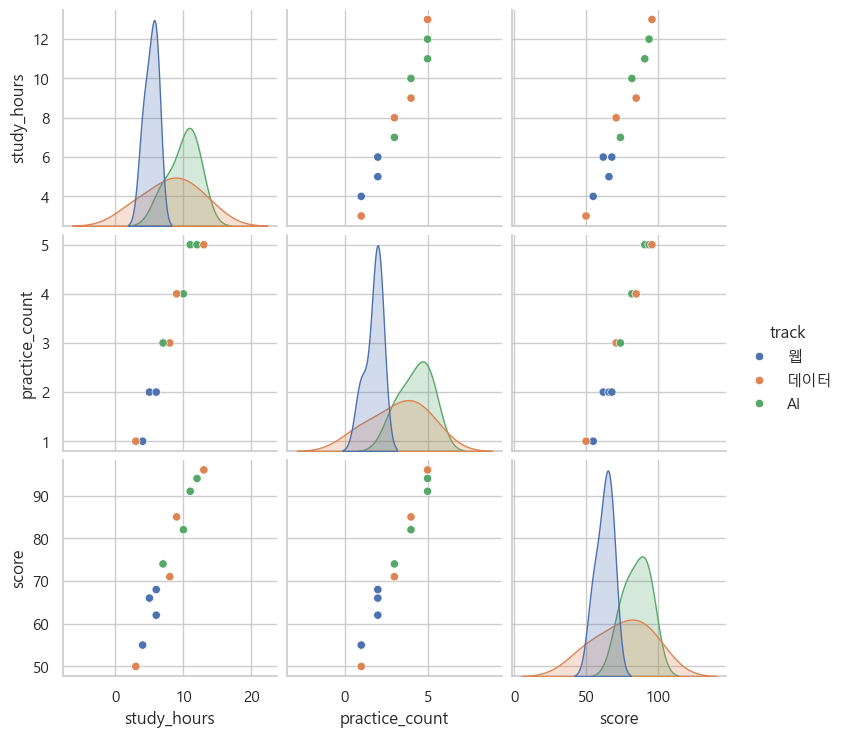

In [18]:
student_df = pd.DataFrame({
    'study_hours': [4, 6, 3, 8, 10, 7, 5, 9, 11, 6, 12, 13],
    'practice_count': [1, 2, 1, 3, 4, 3, 2, 4, 5, 2, 5, 5],
    'score': [55, 62, 50, 71, 82, 74, 66, 85, 91, 68, 94, 96],
    'track': ['웹', '웹', '데이터', '데이터', 'AI', 'AI', '웹', '데이터', 'AI', '웹', 'AI', '데이터'],
    'level': ['입문', '입문', '입문', '기초', '기초', '기초', '기초', '중급', '중급', '중급', '중급', '중급'],
    'completed': ['N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y']
})

# 1. study_hours, practice_count, score, track 컬럼만 선택한다.
# 2. hue='track'으로 pairplot을 그린다.

# 주의
# - pairplot은 figure-level 함수라 plt.figure()를 따로 만들지 않아도 된다.

# TODO: pairplot 완성하기
sns.pairplot(student_df[['study_hours', 'practice_count', 'score', 'track']], hue='track')
plt.show()